# Deteksi Kecanduan Smartphone Menggunakan Hybrid XGBoost + CNN dengan Optimasi Hyperparameter

**Judul Penelitian:** Deteksi Kecanduan Smartphone Menggunakan Metode Hybrid XGBoost dan Convolutional Neural Network dengan Optuna Hyperparameter Optimization

**Deskripsi:** Notebook ini merupakan implementasi yang telah ditingkatkan dari model sebelumnya dengan penambahan:
- Exploratory Data Analysis (EDA) lengkap untuk keperluan jurnal
- Feature Engineering yang lebih baik (interaction features, binning)
- Optuna Hyperparameter Tuning untuk XGBoost dan CNN
- Cross-Validation (Stratified K-Fold) sebagai pengganti single split
- SMOTE untuk menangani class imbalance
- Evaluasi komprehensif: F1-Score, ROC-AUC, Cohen's Kappa, MCC
- Visualisasi lengkap: Confusion Matrix, ROC Curve, SHAP Explainability
- Perbandingan model (Baseline vs Improved)


## 1. Import Library

In [1]:
# ============================
# INSTALL DEPENDENCIES
# ============================
# Jalankan sekali jika belum terinstall
# !pip install optuna shap imbalanced-learn xgboost tensorflow scikit-learn matplotlib seaborn

# Basic
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay
)

# Imbalanced
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, Flatten, MaxPooling1D, Input,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP Explainability
import shap

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Semua library berhasil diimport!")
print(f"TensorFlow version: {tf.__version__}")

✅ Semua library berhasil diimport!
TensorFlow version: 2.21.0


## 2. Load Dataset

In [2]:
# ============================
# LOAD DATASET
# ============================
# Sesuaikan path dengan lokasi file Anda
FILE_PATH = 'E:\\Python - Project\\phone-addiction-detection\\Data\\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'

df = pd.read_csv(FILE_PATH)

print(f"Shape dataset: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
df.head()

Shape dataset: (7500, 16)

Kolom: ['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## 3. Exploratory Data Analysis (EDA)

In [3]:
# ============================
# 3.1 INFORMASI DASAR DATASET
# ============================
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(df.info())
print("\n")
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe().round(2)

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level  

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


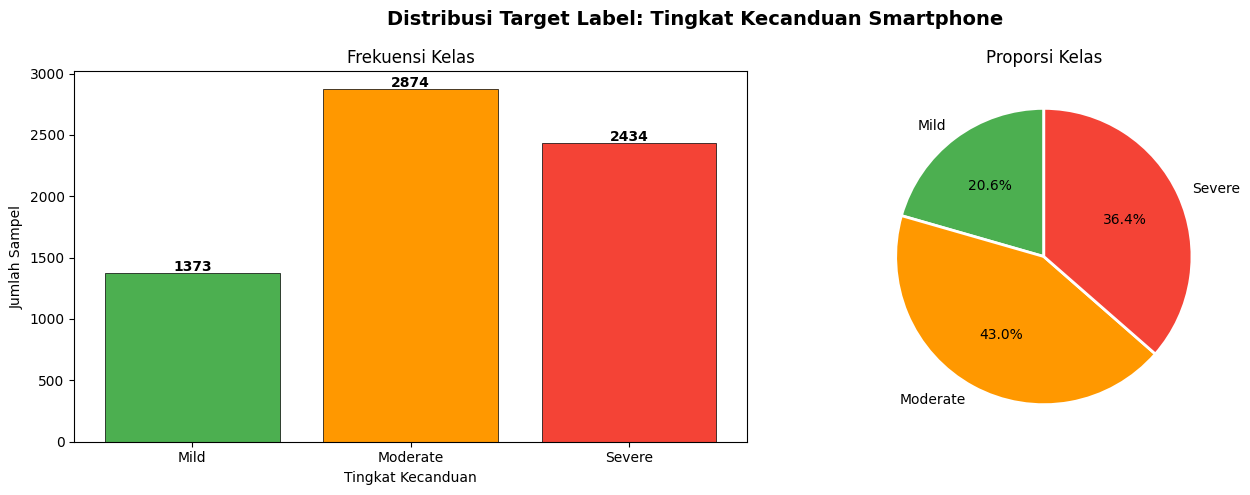


Jumlah sampel per kelas:
addiction_level
Mild        1373
Moderate    2874
Severe      2434
Name: count, dtype: int64


In [4]:
# ============================
# 3.2 DISTRIBUSI TARGET LABEL
# ============================
TARGET = 'addiction_level'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Target Label: Tingkat Kecanduan Smartphone', fontsize=14, fontweight='bold')

# Count plot
order = ['Mild', 'Moderate', 'Severe']
colors = ['#4CAF50', '#FF9800', '#F44336']
df_clean = df.dropna(subset=[TARGET])

counts = df_clean[TARGET].value_counts()[order]
axes[0].bar(order, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Frekuensi Kelas')
axes[0].set_xlabel('Tingkat Kecanduan')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.savefig('fig1_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nJumlah sampel per kelas:")
print(counts)

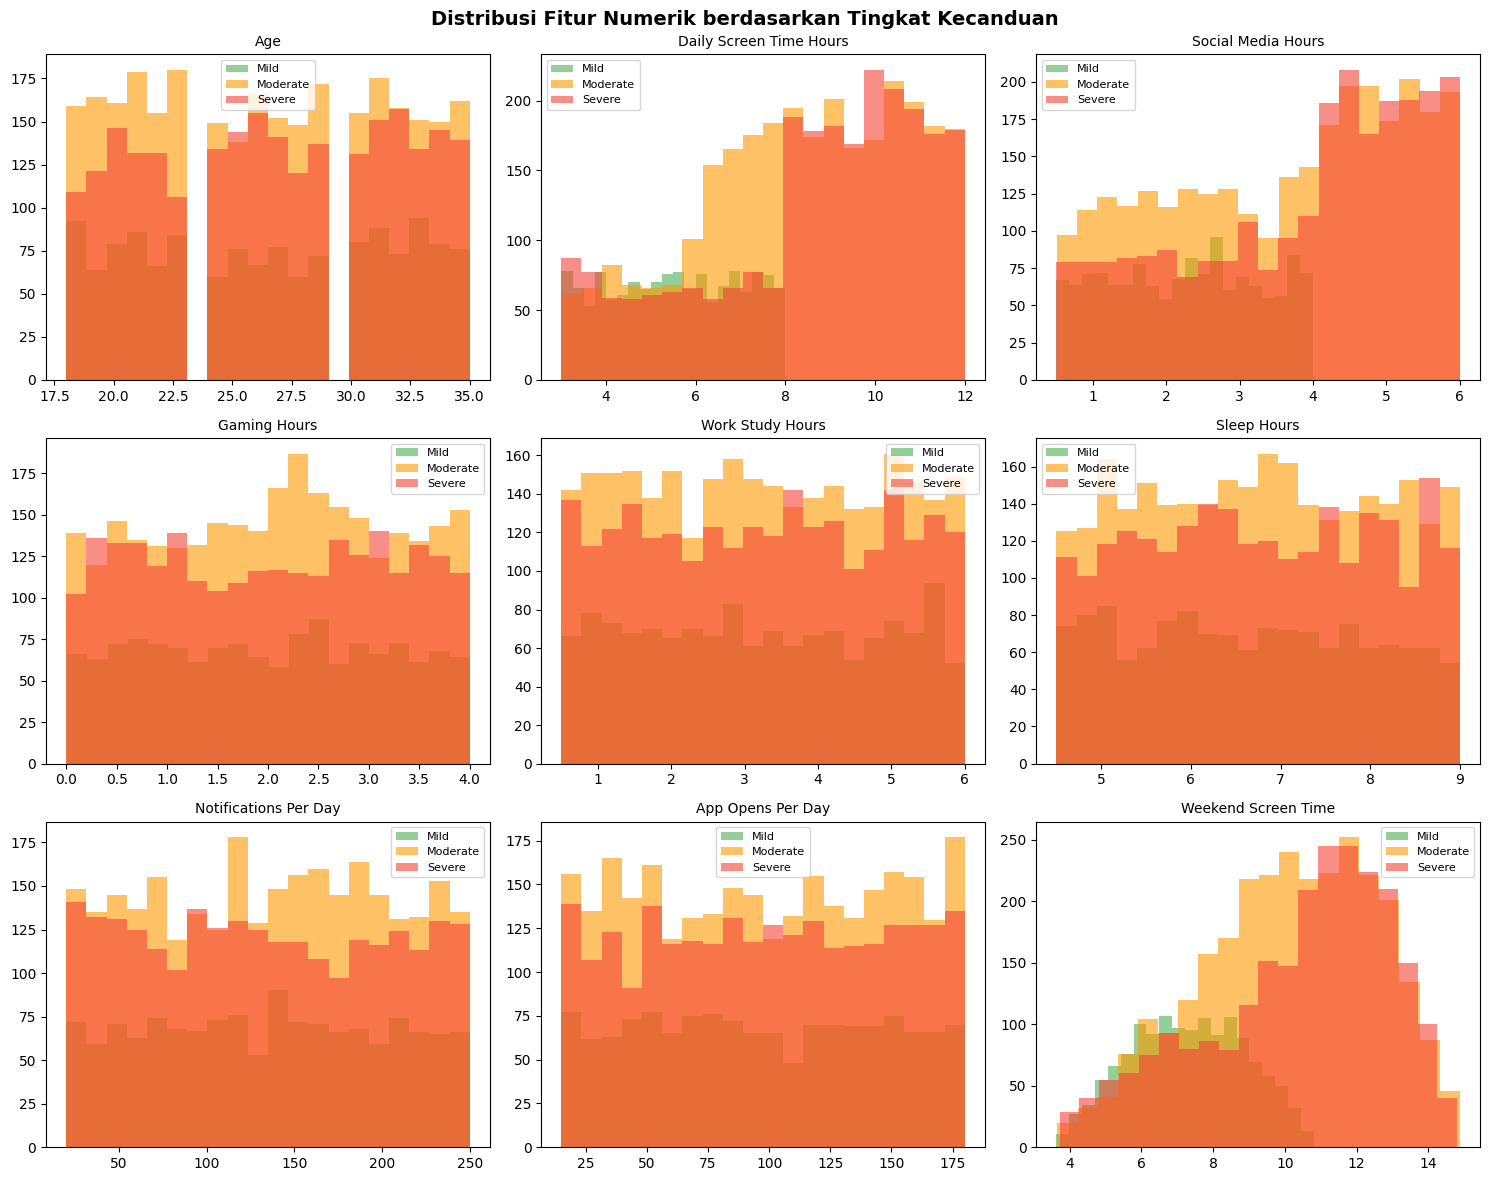

In [5]:
# ============================
# 3.3 DISTRIBUSI FITUR NUMERIK
# ============================
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
                'gaming_hours', 'work_study_hours', 'sleep_hours',
                'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Fitur Numerik berdasarkan Tingkat Kecanduan', fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = {'Mild': '#4CAF50', 'Moderate': '#FF9800', 'Severe': '#F44336'}

for i, col in enumerate(numeric_cols):
    for label in order:
        subset = df_clean[df_clean[TARGET] == label][col]
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=palette[label])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

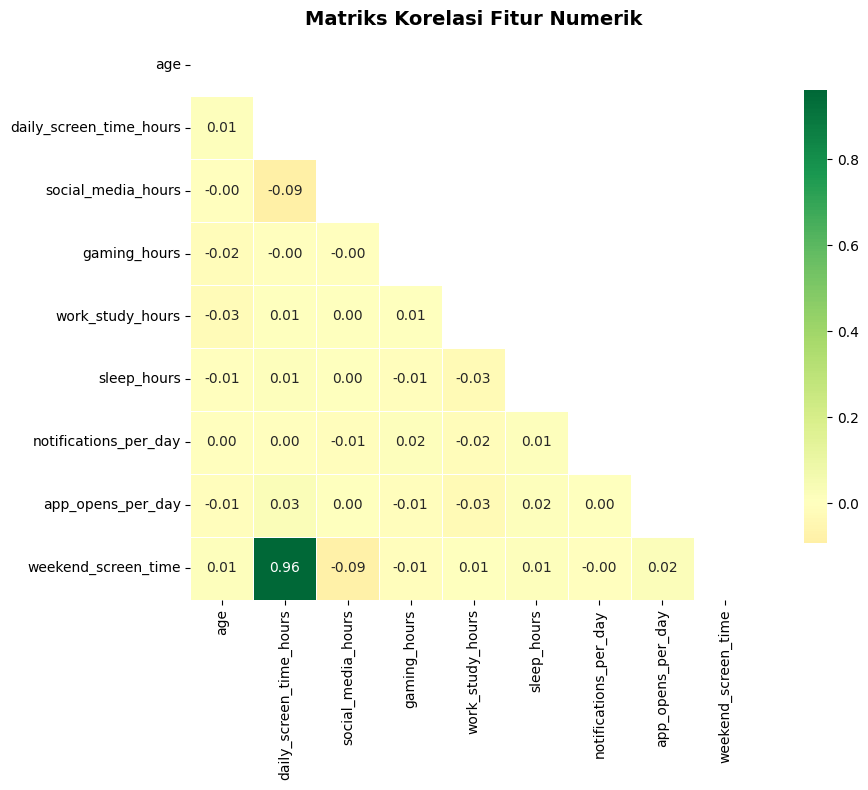

In [6]:
# ============================
# 3.4 KORELASI ANTAR FITUR
# ============================
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

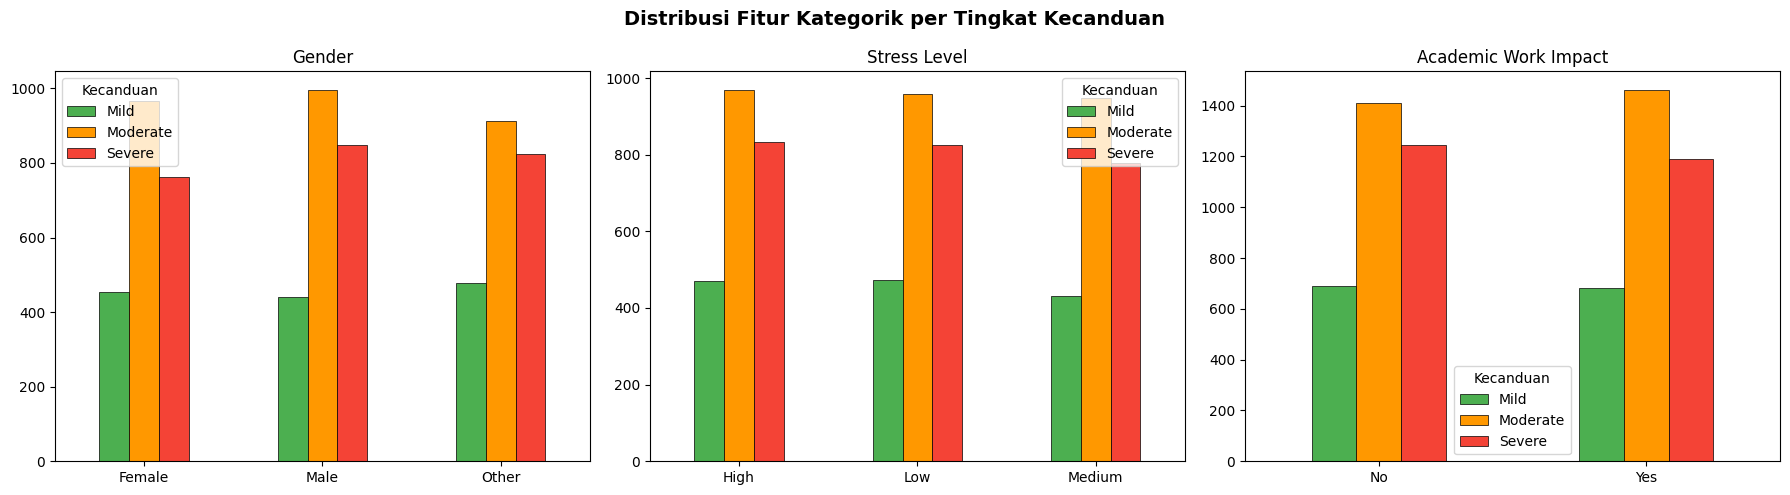

In [7]:
# ============================
# 3.5 ANALISIS KATEGORIK
# ============================
cat_cols = ['gender', 'stress_level', 'academic_work_impact']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Fitur Kategorik per Tingkat Kecanduan', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean[TARGET])
    ct = ct[order] if all(c in ct.columns for c in order) else ct
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Kecanduan')

plt.tight_layout()
plt.savefig('fig4_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Feature Engineering

In [8]:
# ============================
# 4.1 HAPUS MISSING VALUE TARGET
# ============================
df_model = df.dropna(subset=[TARGET]).copy()
print(f"Sebelum hapus NaN: {df.shape[0]} baris")
print(f"Setelah hapus NaN: {df_model.shape[0]} baris")
print(f"Baris dihapus: {df.shape[0] - df_model.shape[0]} baris")

Sebelum hapus NaN: 7500 baris
Setelah hapus NaN: 6681 baris
Baris dihapus: 819 baris


In [9]:
# ============================
# 4.2 FEATURE ENGINEERING
# IMPROVEMENT: Tambah fitur interaksi dan agregasi
# ============================

# Rasio penggunaan sosial media terhadap total screen time
df_model['social_ratio'] = df_model['social_media_hours'] / (df_model['daily_screen_time_hours'] + 1e-5)

# Rasio gaming terhadap total
df_model['gaming_ratio'] = df_model['gaming_hours'] / (df_model['daily_screen_time_hours'] + 1e-5)

# Total leisure time (non-work screen time)
df_model['leisure_time'] = df_model['social_media_hours'] + df_model['gaming_hours']

# Sleep deficit (kurang dari 7 jam dianggap defisit)
df_model['sleep_deficit'] = np.maximum(0, 7 - df_model['sleep_hours'])

# Notification density (per jam screen time)
df_model['notification_density'] = df_model['notifications_per_day'] / (df_model['daily_screen_time_hours'] + 1e-5)

# App open rate per hour
df_model['app_open_rate'] = df_model['app_opens_per_day'] / (df_model['daily_screen_time_hours'] + 1e-5)

# Weekend vs weekday ratio
df_model['weekend_weekday_ratio'] = df_model['weekend_screen_time'] / (df_model['daily_screen_time_hours'] + 1e-5)

# Screen time bin
df_model['screen_time_bin'] = pd.cut(
    df_model['daily_screen_time_hours'],
    bins=[0, 3, 6, 9, 15],
    labels=[0, 1, 2, 3]
).astype(float)

print("✅ Feature Engineering selesai!")
print(f"Jumlah fitur awal: {len(numeric_cols) + len(cat_cols)}")
print(f"Jumlah fitur setelah FE: {df_model.shape[1] - 4}")  # -4 for id, target, etc

✅ Feature Engineering selesai!
Jumlah fitur awal: 12
Jumlah fitur setelah FE: 20


In [10]:
# ============================
# 4.3 ENCODE FITUR & TARGET
# ============================
drop_cols = ['transaction_id', 'user_id', 'addicted_label']

X = df_model.drop(columns=[TARGET] + drop_cols)
y_raw = df_model[TARGET]

# Encode target dengan urutan yang bermakna
target_order = ['Mild', 'Moderate', 'Severe']
target_mapping = {v: i for i, v in enumerate(target_order)}
y = y_raw.map(target_mapping).values

print(f"Mapping target: {target_mapping}")
print(f"Distribusi y: {pd.Series(y).value_counts().sort_index().to_dict()}")

# Encode fitur kategorik dengan OrdinalEncoder (lebih robust)
cat_features = X.select_dtypes(include='object').columns.tolist()
print(f"\nFitur kategorik: {cat_features}")

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Handle NaN (jika ada)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_imputed = X_imputed.replace([np.inf, -np.inf], 0).fillna(0)

print(f"\nTotal NaN setelah preprocessing: {X_imputed.isnull().sum().sum()}")
print(f"Shape X: {X_imputed.shape}, Shape y: {y.shape}")

Mapping target: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
Distribusi y: {0: 1373, 1: 2874, 2: 2434}

Fitur kategorik: ['gender', 'stress_level', 'academic_work_impact']

Total NaN setelah preprocessing: 0
Shape X: (6681, 20), Shape y: (6681,)


In [11]:
# ============================
# 4.4 TRAIN TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

# Cek distribusi kelas
print("\nDistribusi kelas pada train:")
for i, name in enumerate(target_order):
    count = (y_train == i).sum()
    pct = count / len(y_train) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

Train size: (5344, 20)
Test size : (1337, 20)

Distribusi kelas pada train:
  Mild: 1098 (20.5%)
  Moderate: 2299 (43.0%)
  Severe: 1947 (36.4%)


In [12]:
# ============================
# 4.5 SMOTE - HANDLE CLASS IMBALANCE
# IMPROVEMENT: Menggunakan SMOTE untuk menyeimbangkan kelas
# ============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribusi setelah SMOTE:")
for i, name in enumerate(target_order):
    count = (y_train_sm == i).sum()
    pct = count / len(y_train_sm) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Reshape untuk CNN
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"\nShape CNN input: {X_train_cnn.shape}")

Distribusi setelah SMOTE:
  Mild: 2299 (33.3%)
  Moderate: 2299 (33.3%)
  Severe: 2299 (33.3%)

Shape CNN input: (6897, 20, 1)


## 5. Hyperparameter Optimization dengan Optuna

In [13]:
# ============================
# 5.1 OPTUNA - TUNING XGBOOST
# IMPROVEMENT: Hyperparameter tuning otomatis
# ============================
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'eval_metric': 'mlogloss',
        'use_label_encoder': False,
        'random_state': 42
    }

    model = XGBClassifier(**params)

    # Stratified K-Fold Cross Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train_sm,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("🔍 Menjalankan Optuna untuk XGBoost (50 trials)...")
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
print(f"\n✅ Best XGBoost params: {best_xgb_params}")
print(f"Best F1-Macro CV Score: {study_xgb.best_value:.4f}")

🔍 Menjalankan Optuna untuk XGBoost (50 trials)...


Best trial: 47. Best value: 0.670447: 100%|██████████| 50/50 [03:04<00:00,  3.68s/it]


✅ Best XGBoost params: {'n_estimators': 119, 'max_depth': 9, 'learning_rate': 0.09547165121171687, 'subsample': 0.807661012560118, 'colsample_bytree': 0.9633618753531885, 'min_child_weight': 5, 'gamma': 0.18484917843286516, 'reg_alpha': 0.06789570643151491, 'reg_lambda': 0.025041389583547822}
Best F1-Macro CV Score: 0.6704


In [14]:
# ============================
# 5.2 OPTUNA - TUNING CNN
# IMPROVEMENT: Otomatis cari arsitektur CNN terbaik
# ============================
n_classes = len(target_order)
n_features = X_train_cnn.shape[1]

def build_cnn(trial, input_shape, n_classes):
    """Build CNN dengan hyperparameter dari Optuna"""
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Layer Conv1D 1
    filters1 = trial.suggest_categorical('filters1', [32, 64, 128])
    kernel1 = trial.suggest_categorical('kernel1', [2, 3])
    model.add(Conv1D(filters1, kernel_size=kernel1, activation='relu',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(trial.suggest_float('dropout1', 0.2, 0.5)))

    # Layer Conv1D 2
    n_layers = trial.suggest_int('n_conv_layers', 1, 2)
    if n_layers >= 2:
        filters2 = trial.suggest_categorical('filters2', [64, 128, 256])
        model.add(Conv1D(filters2, kernel_size=2, activation='relu',
                         kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        if X_train_cnn.shape[1] > 10:
            model.add(MaxPooling1D(pool_size=2))
        model.add(Dropout(trial.suggest_float('dropout2', 0.2, 0.5)))

    model.add(Flatten())

    # Dense layers
    dense_units = trial.suggest_categorical('dense_units', [64, 128, 256])
    model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(trial.suggest_float('dropout_dense', 0.2, 0.5)))
    model.add(Dense(n_classes, activation='softmax'))

    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def objective_cnn(trial):
    model = build_cnn(trial, (n_features, 1), n_classes)
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    history = model.fit(
        X_train_cnn, y_train_sm,
        validation_split=0.2,
        epochs=50,
        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
        callbacks=[early_stop],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    return val_acc

print("🔍 Menjalankan Optuna untuk CNN (20 trials)...")
study_cnn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cnn.optimize(objective_cnn, n_trials=20, show_progress_bar=True)

best_cnn_params = study_cnn.best_params
print(f"\n✅ Best CNN params: {best_cnn_params}")
print(f"Best Val Accuracy: {study_cnn.best_value:.4f}")

🔍 Menjalankan Optuna untuk CNN (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 13. Best value: 0.950725: 100%|██████████| 20/20 [08:42<00:00, 26.10s/it]


✅ Best CNN params: {'filters1': 64, 'kernel1': 3, 'dropout1': 0.3034060552379113, 'n_conv_layers': 2, 'filters2': 256, 'dropout2': 0.45390624902637655, 'dense_units': 128, 'dropout_dense': 0.3490596613036471, 'lr': 0.0015867879980833248, 'batch_size': 128}
Best Val Accuracy: 0.9507


## 6. Training Model dengan Parameter Optimal

In [15]:
# ============================
# 6.1 TRAINING XGBOOST OPTIMAL
# ============================
best_xgb_params.update({'eval_metric': 'mlogloss', 'random_state': 42})
xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(
    X_train_scaled, y_train_sm,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)
print("✅ XGBoost selesai training!")

✅ XGBoost selesai training!


In [16]:
# ============================
# 6.2 TRAINING CNN OPTIMAL
# ============================
cnn_model = build_cnn(
    study_cnn.best_trial,
    (n_features, 1),
    n_classes
)
cnn_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

batch_size = best_cnn_params.get('batch_size', 64)
history = cnn_model.fit(
    X_train_cnn, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ CNN selesai training!")

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 8, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,147 (649.01 KB)

 Trainable params: 165,507 (646.51 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5037 - loss: 1.5995 - val_accuracy: 0.6341 - val_loss: 1.2582 - learning_rate: 0.0016
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5443 - loss: 1.1528 - val_accuracy: 0.3101 - val_loss: 1.4149 - learning_rate: 0.0016
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5530 - loss: 1.0916 - val_accuracy: 0.4739 - val_loss: 1.1458 - learning_rate: 0.0016
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5565 - loss: 1.0605 - val_accuracy: 0.6355 - val_loss: 0.9476 - learning_rate: 0.0016
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5652 - loss: 1.0411 - val_accuracy: 0.7862 - val_loss: 0.7673 - learning_rate: 0.0016
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5668 - loss: 1.0174 - val_accuracy: 0.8406 - val_loss: 0.6635 - learning_rate: 0.0016
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5757 - loss: 0.9965 - 

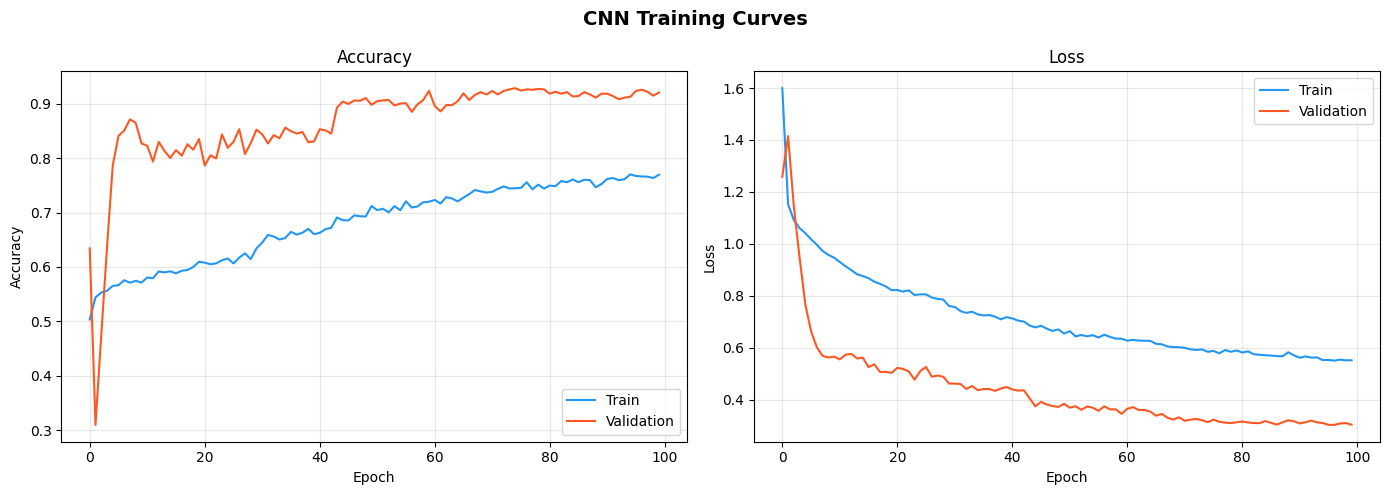

In [17]:
# ============================
# 6.3 TRAINING CURVE CNN
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'], label='Train', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#FF5722')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#2196F3')
axes[1].plot(history.history['val_loss'], label='Validation', color='#FF5722')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hybrid Ensemble (Stacking)

In [18]:
# ============================
# 7.1 STACKING META-LEARNER
# IMPROVEMENT: Stacking yang benar menggunakan semua probabilitas
# ============================

# Probabilitas dari training set untuk meta-learner
xgb_train_prob = xgb_model.predict_proba(X_train_scaled)  # shape: (n, 3)
cnn_train_prob = cnn_model.predict(X_train_cnn)            # shape: (n, 3)

# Gabungkan semua probabilitas (6 fitur meta)
stack_train = np.hstack([xgb_train_prob, cnn_train_prob])

# Probabilitas dari test set
xgb_test_prob = xgb_model.predict_proba(X_test_scaled)
cnn_test_prob = cnn_model.predict(X_test_cnn)
stack_test = np.hstack([xgb_test_prob, cnn_test_prob])

# Meta-learner: Logistic Regression dengan tuning C
from sklearn.model_selection import GridSearchCV
meta_params = {'C': [0.01, 0.1, 1, 10]}
meta_cv = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        meta_params, cv=5, scoring='f1_macro')
meta_cv.fit(stack_train, y_train_sm)
meta_model = meta_cv.best_estimator_

print(f"✅ Meta-learner terbaik: C={meta_cv.best_params_['C']}")
print(f"CV F1-Macro: {meta_cv.best_score_:.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Meta-learner terbaik: C=0.1
CV F1-Macro: 0.9997


In [19]:
# ============================
# 7.2 PREDIKSI AKHIR
# ============================
xgb_pred = xgb_model.predict(X_test_scaled)
cnn_pred  = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
hybrid_pred = meta_model.predict(stack_test)
hybrid_prob = meta_model.predict_proba(stack_test)

print("Prediksi berhasil!")
print(f"XGBoost - sample pred: {xgb_pred[:10]}")
print(f"CNN     - sample pred: {cnn_pred[:10]}")
print(f"Hybrid  - sample pred: {hybrid_pred[:10]}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Prediksi berhasil!
XGBoost - sample pred: [1 0 1 0 0 2 2 2 2 2]
CNN     - sample pred: [2 2 2 0 0 1 2 2 1 2]
Hybrid  - sample pred: [1 1 1 0 0 2 2 2 2 2]


## 8. Evaluasi Komprehensif

In [20]:
# ============================
# 8.1 FUNGSI EVALUASI LENGKAP
# IMPROVEMENT: Tambah Kappa, MCC, dan F1 per kelas
# ============================
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Evaluasi komprehensif untuk jurnal ilmiah"""
    print(f"\n{'='*60}")
    print(f"  EVALUASI: {name}")
    print(f"{'='*60}")

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy         : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1-Score (Macro) : {f1_macro:.4f}")
    print(f"  F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"  Cohen's Kappa    : {kappa:.4f}")
    print(f"  MCC              : {mcc:.4f}")

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        print(f"  ROC-AUC (Macro)  : {auc:.4f}")
    else:
        auc = None

    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=target_order))

    return {
        'model': name, 'accuracy': acc, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'kappa': kappa, 'mcc': mcc, 'auc': auc
    }


# Evaluasi tiap model
results = []
results.append(evaluate_model('XGBoost (Tuned)', y_test, xgb_pred, xgb_test_prob))
results.append(evaluate_model('CNN (Tuned)', y_test, cnn_pred, cnn_test_prob))
results.append(evaluate_model('Hybrid XGBoost+CNN', y_test, hybrid_pred, hybrid_prob))


  EVALUASI: XGBoost (Tuned)
  Accuracy         : 0.5759 (57.59%)
  F1-Score (Macro) : 0.6153
  F1-Score (Weighted): 0.5713
  Cohen's Kappa    : 0.3437
  MCC              : 0.3441
  ROC-AUC (Macro)  : 0.7782

  Classification Report:
              precision    recall  f1-score   support

        Mild       0.79      0.89      0.84       275
    Moderate       0.51      0.47      0.49       575
      Severe       0.51      0.52      0.52       487

    accuracy                           0.58      1337
   macro avg       0.60      0.63      0.62      1337
weighted avg       0.57      0.58      0.57      1337


  EVALUASI: CNN (Tuned)
  Accuracy         : 0.5512 (55.12%)
  F1-Score (Macro) : 0.5908
  F1-Score (Weighted): 0.5448
  Cohen's Kappa    : 0.3077
  MCC              : 0.3096
  ROC-AUC (Macro)  : 0.7549

  Classification Report:
              precision    recall  f1-score   support

        Mild       0.78      0.86      0.82       275
    Moderate       0.48      0.40      0.43   


TABEL PERBANDINGAN MODEL
                    Accuracy  F1-Macro  F1-Weighted  Cohen's Kappa     MCC  ROC-AUC
model                                                                              
XGBoost (Tuned)       0.5759    0.6153       0.5713         0.3437  0.3441   0.7782
CNN (Tuned)           0.5512    0.5908       0.5448         0.3077  0.3096   0.7549
Hybrid XGBoost+CNN    0.5737    0.6140       0.5707         0.3378  0.3379   0.7686


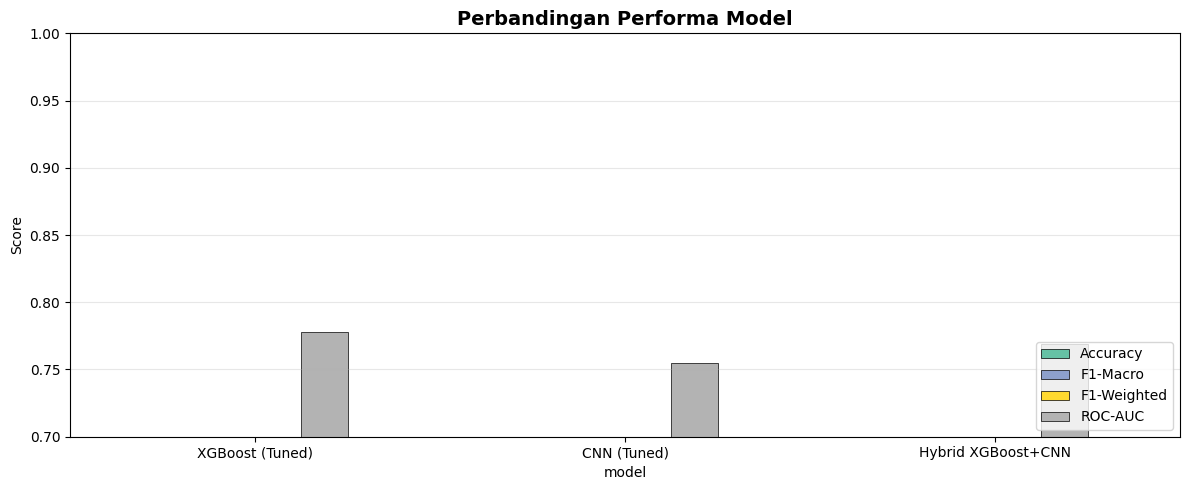

In [21]:
# ============================
# 8.2 TABEL PERBANDINGAN MODEL
# ============================
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['accuracy', 'f1_macro', 'f1_weighted', 'kappa', 'mcc', 'auc']]
results_df.columns = ['Accuracy', 'F1-Macro', 'F1-Weighted', "Cohen's Kappa", 'MCC', 'ROC-AUC']
print("\n" + "="*70)
print("TABEL PERBANDINGAN MODEL")
print("="*70)
print(results_df.round(4).to_string())

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
results_df[['Accuracy', 'F1-Macro', 'F1-Weighted', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5
)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

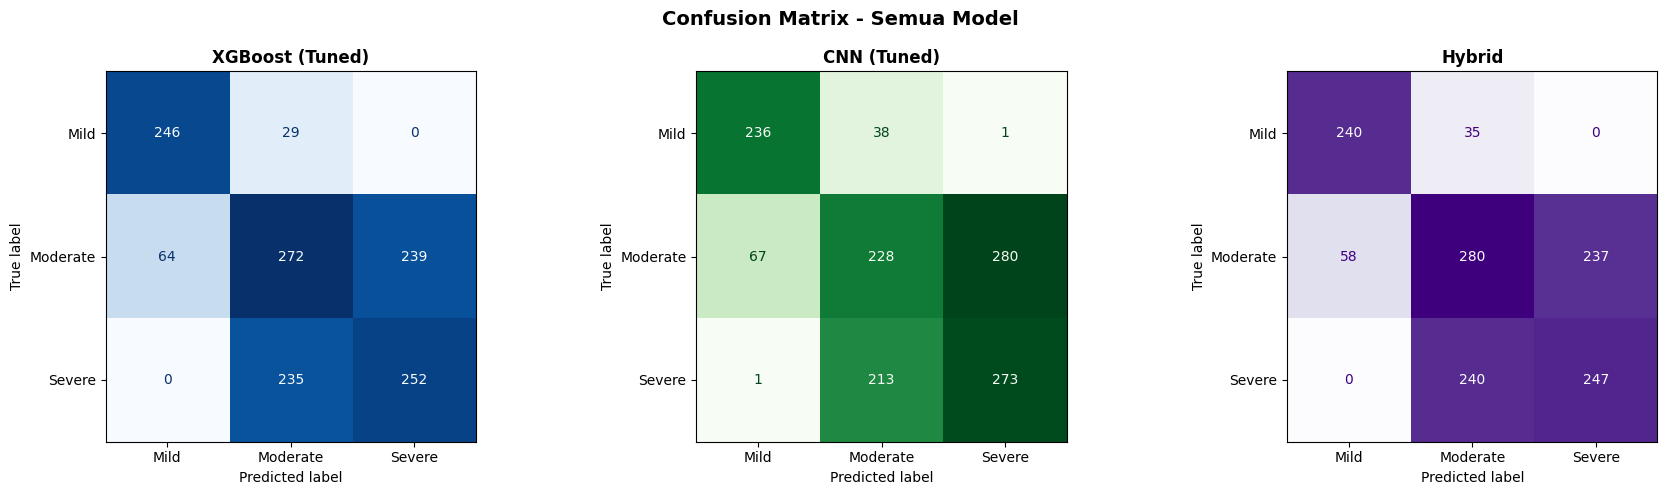

In [22]:
# ============================
# 8.3 CONFUSION MATRIX
# ============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix - Semua Model', fontsize=14, fontweight='bold')

models_preds = [('XGBoost (Tuned)', xgb_pred), ('CNN (Tuned)', cnn_pred), ('Hybrid', hybrid_pred)]
cmaps = ['Blues', 'Greens', 'Purples']

for ax, (name, pred), cmap in zip(axes, models_preds, cmaps):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_order)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

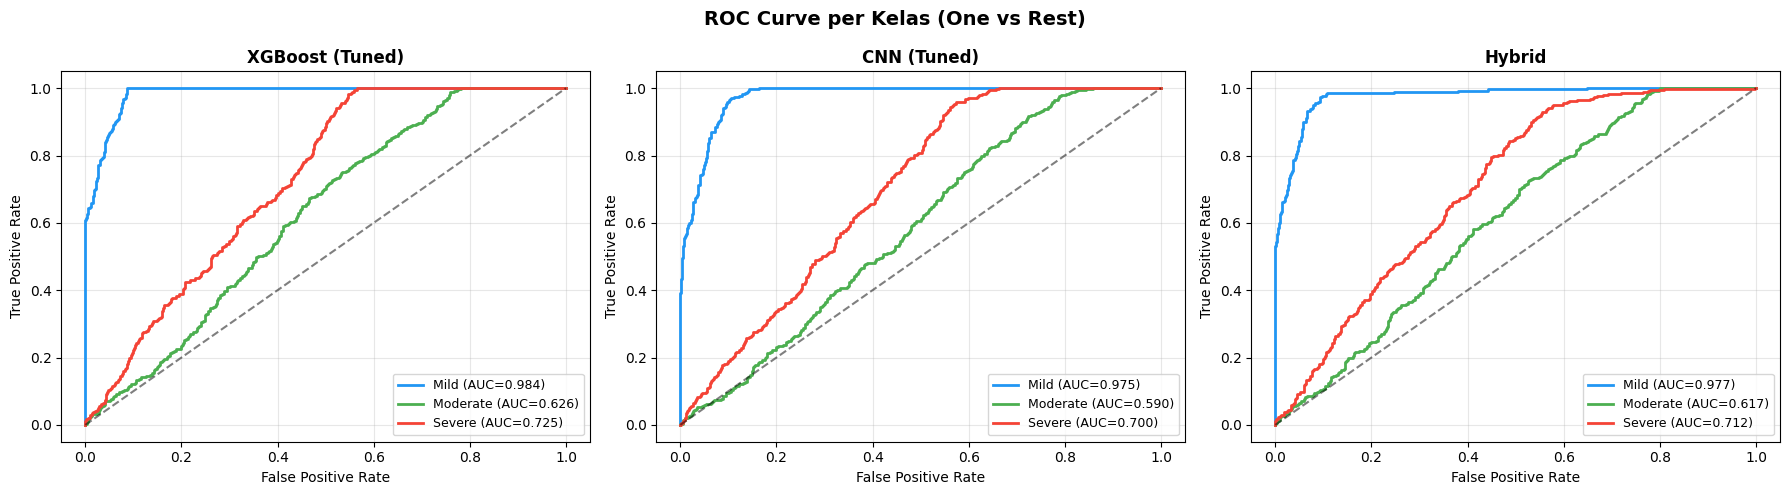

In [23]:
# ============================
# 8.4 ROC CURVE (OvR - Multiclass)
# ============================
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curve per Kelas (One vs Rest)', fontsize=14, fontweight='bold')

model_probs = [
    ('XGBoost (Tuned)', xgb_test_prob),
    ('CNN (Tuned)', cnn_test_prob),
    ('Hybrid', hybrid_prob)
]

line_colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, (name, prob) in zip(axes, model_probs):
    for i, (cls_name, color) in enumerate(zip(target_order, line_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_name} (AUC={auc_score:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-Validation (K-Fold)

In [24]:
# ============================
# 9.1 STRATIFIED K-FOLD CV
# IMPROVEMENT: Validasi lebih robust untuk jurnal
# ============================
print("🔄 Menjalankan 5-Fold Cross-Validation...")

# Siapkan data keseluruhan (sebelum split)
X_full_scaled = scaler.fit_transform(X_imputed)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {'XGBoost': [], 'CNN': [], 'Hybrid': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full_scaled, y)):
    print(f"\n  Fold {fold+1}/5...")

    X_tr, X_val = X_full_scaled[train_idx], X_full_scaled[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # SMOTE per fold
    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    # --- XGBoost ---
    xgb_fold = XGBClassifier(**best_xgb_params)
    xgb_fold.fit(X_tr_sm, y_tr_sm)
    xgb_fold_pred = xgb_fold.predict(X_val)
    cv_results['XGBoost'].append(f1_score(y_val, xgb_fold_pred, average='macro'))

    # --- CNN ---
    X_tr_cnn = X_tr_sm.reshape(X_tr_sm.shape[0], X_tr_sm.shape[1], 1)
    X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

    cnn_fold = build_cnn(study_cnn.best_trial, (n_features, 1), n_classes)
    cnn_fold.fit(X_tr_cnn, y_tr_sm, epochs=50, batch_size=64,
                  validation_split=0.1,
                  callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
                  verbose=0)
    cnn_fold_pred = np.argmax(cnn_fold.predict(X_val_cnn, verbose=0), axis=1)
    cv_results['CNN'].append(f1_score(y_val, cnn_fold_pred, average='macro'))

    # --- Hybrid ---
    st_tr = np.hstack([xgb_fold.predict_proba(X_tr_sm),
                        cnn_fold.predict(X_tr_cnn, verbose=0)])
    st_val = np.hstack([xgb_fold.predict_proba(X_val),
                         cnn_fold.predict(X_val_cnn, verbose=0)])
    meta_fold = LogisticRegression(C=meta_cv.best_params_['C'], max_iter=1000)
    meta_fold.fit(st_tr, y_tr_sm)
    hybrid_fold_pred = meta_fold.predict(st_val)
    cv_results['Hybrid'].append(f1_score(y_val, hybrid_fold_pred, average='macro'))

print("\n" + "="*60)
print("HASIL CROSS-VALIDATION (F1-Macro)")
print("="*60)
for model_name, scores in cv_results.items():
    print(f"{model_name:20s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

🔄 Menjalankan 5-Fold Cross-Validation...

  Fold 1/5...

  Fold 2/5...

  Fold 3/5...

  Fold 4/5...

  Fold 5/5...

HASIL CROSS-VALIDATION (F1-Macro)
XGBoost             : 0.6096 ± 0.0087
CNN                 : 0.5477 ± 0.0202
Hybrid              : 0.6070 ± 0.0113


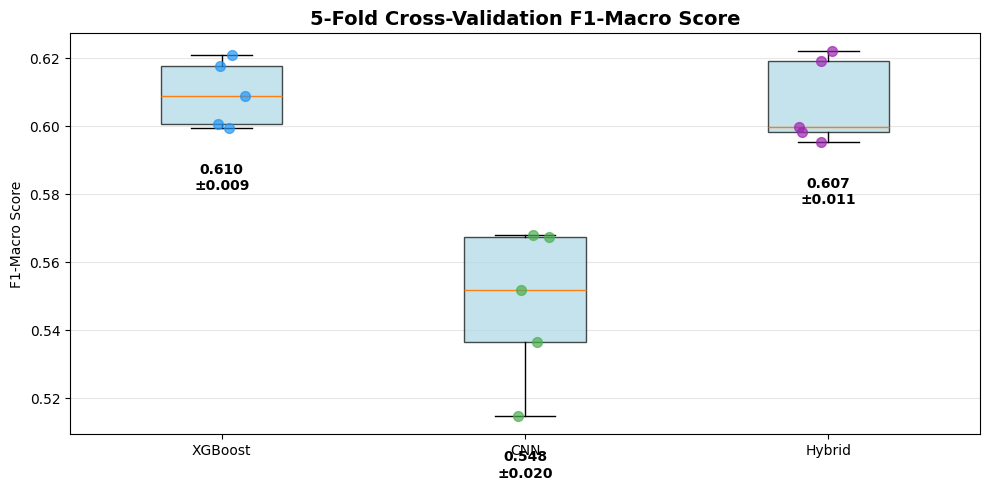

In [25]:
# ============================
# 9.2 VISUALISASI CV RESULTS
# ============================
fig, ax = plt.subplots(figsize=(10, 5))

cv_df = pd.DataFrame(cv_results)
positions = [1, 2, 3]
bp = ax.boxplot(cv_df.values, positions=positions,
                patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', alpha=0.7))

for i, (model_name, scores) in enumerate(cv_results.items()):
    x = np.random.normal(positions[i], 0.05, size=len(scores))
    ax.scatter(x, scores, alpha=0.7, color=['#2196F3', '#4CAF50', '#9C27B0'][i], zorder=3, s=50)

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys())
ax.set_title('5-Fold Cross-Validation F1-Macro Score', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Macro Score')
ax.grid(axis='y', alpha=0.3)

for i, (model_name, scores) in enumerate(cv_results.items()):
    ax.text(positions[i], min(scores) - 0.01,
            f'{np.mean(scores):.3f}\n±{np.std(scores):.3f}',
            ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig9_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Explainability dengan SHAP

🔍 Menghitung SHAP values...


<Figure size 1000x700 with 0 Axes>

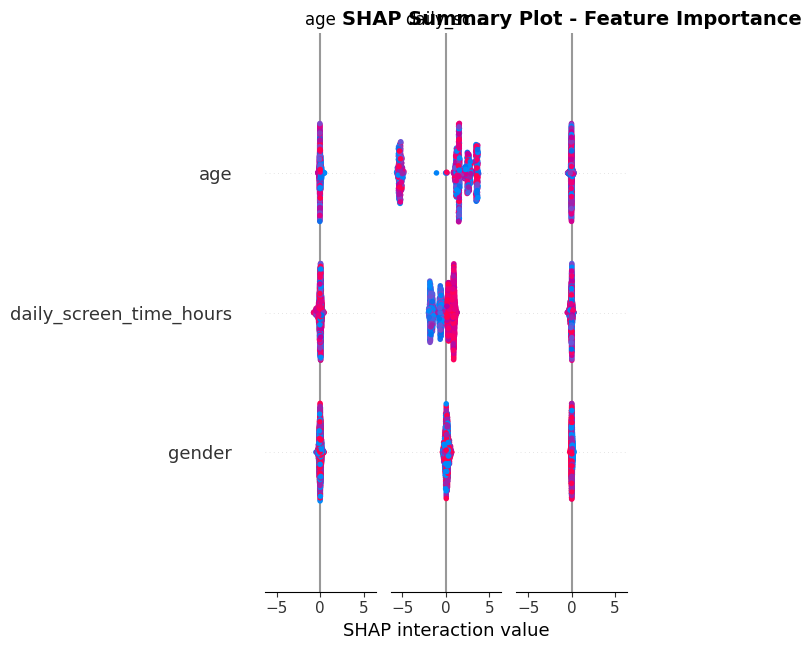

In [26]:
# ============================
# 10.1 SHAP FEATURE IMPORTANCE (XGBoost)
# IMPROVEMENT: SHAP lebih informatif dari feature importance biasa
# ============================
print("🔍 Menghitung SHAP values...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_imputed.columns.tolist(),
    class_names=target_order,
    show=False
)
plt.title('SHAP Summary Plot - Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Eval


In [29]:
# ============================
# 11.1 TABEL AKHIR KOMPREHENSIF
# ============================
print("\n" + "="*70)
print("  RINGKASAN HASIL PENELITIAN")
print("  Deteksi Kecanduan Smartphone: Hybrid XGBoost + CNN")
print("="*70)

print("\n📊 A. HASIL PADA TEST SET (80:20 Split)")
print("-"*70)
display_df = results_df.copy()
print(display_df.round(4).to_string())

print("\n📊 B. HASIL CROSS-VALIDATION (5-Fold, F1-Macro)")
print("-"*70)
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean F1-Macro': [np.mean(v) for v in cv_results.values()],
    'Std F1-Macro': [np.std(v) for v in cv_results.values()],
    'Min': [np.min(v) for v in cv_results.values()],
    'Max': [np.max(v) for v in cv_results.values()]
}).set_index('Model')
print(cv_summary.round(4).to_string())

print("\n📋 C. KONFIGURASI MODEL TERBAIK")
print("-"*70)
print(f"Dataset: 7500 baris, {X_imputed.shape[1]} fitur (setelah FE)")
print(f"Missing values pada target: 819 baris (dihapus)")
print(f"Setelah preprocessing: {len(df_model)} baris")
print(f"Class balancing: SMOTE")
print(f"Hyperparameter tuning: Optuna (TPE Sampler)")
print(f"  XGBoost - Best params: {best_xgb_params}")
print(f"  CNN     - Best val accuracy: {study_cnn.best_value:.4f}")
print(f"  Meta-learner: LogisticRegression (C={meta_cv.best_params_['C']}")
print("\n✅ Notebook selesai! Semua figure telah disimpan.")


  RINGKASAN HASIL PENELITIAN
  Deteksi Kecanduan Smartphone: Hybrid XGBoost + CNN

📊 A. HASIL PADA TEST SET (80:20 Split)
----------------------------------------------------------------------
                    Accuracy  F1-Macro  F1-Weighted  Cohen's Kappa     MCC  ROC-AUC
model                                                                              
XGBoost (Tuned)       0.5759    0.6153       0.5713         0.3437  0.3441   0.7782
CNN (Tuned)           0.5512    0.5908       0.5448         0.3077  0.3096   0.7549
Hybrid XGBoost+CNN    0.5737    0.6140       0.5707         0.3378  0.3379   0.7686

📊 B. HASIL CROSS-VALIDATION (5-Fold, F1-Macro)
----------------------------------------------------------------------
         Mean F1-Macro  Std F1-Macro     Min     Max
Model                                               
XGBoost         0.6096        0.0087  0.5995  0.6211
CNN             0.5477        0.0202  0.5147  0.5680
Hybrid          0.6070        0.0113  0.5953  0.6222

📋

In [30]:
# ============================
# 11.2 SIMPAN MODEL
# ============================
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# Simpan model
joblib.dump(xgb_model, 'saved_models/xgb_model.pkl')
joblib.dump(meta_model, 'saved_models/meta_model.pkl')
joblib.dump(scaler, 'saved_models/scaler.pkl')
cnn_model.save('saved_models/cnn_model.keras')

print("✅ Model berhasil disimpan di folder 'saved_models/'")
print("  - xgb_model.pkl")
print("  - meta_model.pkl")
print("  - scaler.pkl")
print("  - cnn_model.keras")

✅ Model berhasil disimpan di folder 'saved_models/'
  - xgb_model.pkl
  - meta_model.pkl
  - scaler.pkl
  - cnn_model.keras
